<a href="https://colab.research.google.com/github/riskitrisnanto763-web/PengelolaanCitraDigital/blob/main/UTS_Risky_23423007_no2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

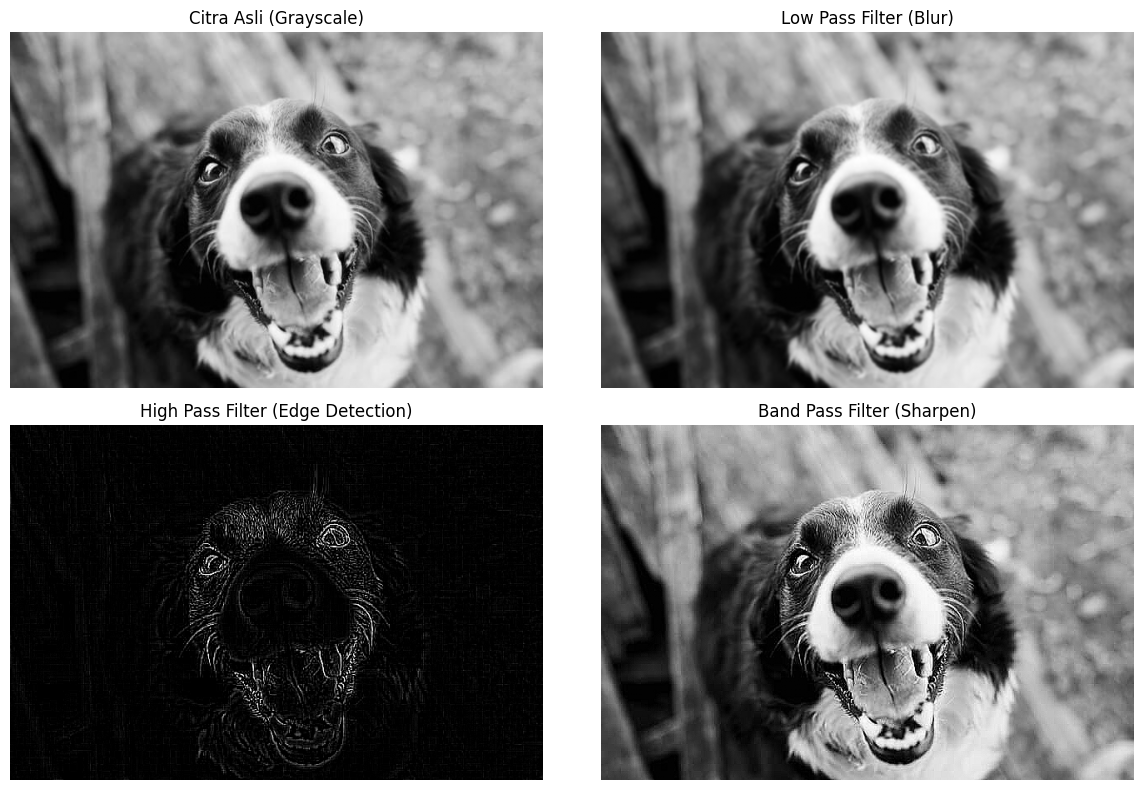

Nilai rata-rata intensitas piksel:
Asli : 120.25
LPF  : 120.25
HPF  : 7.17
BPF  : 120.48


In [1]:
# ============================================================
# 1️⃣ Import library
# ============================================================
import cv2
import numpy as np
import matplotlib.pyplot as plt

# ============================================================
# 2️⃣ Membaca gambar dan konversi ke grayscale
# ============================================================
img = cv2.imread('output-onlinetools.png')   # sesuaikan path jika perlu
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
gray = cv2.cvtColor(img_rgb, cv2.COLOR_RGB2GRAY)

# ============================================================
# 3️⃣ Definisi kernel filter
# ============================================================
# Low Pass Filter (LPF) - Reduksi noise / blur
lpf_kernel = (1/9) * np.array([[1,1,1],
                               [1,1,1],
                               [1,1,1]])

# High Pass Filter (HPF) - Deteksi tepi
hpf_kernel = np.array([[-1,-1,-1],
                       [-1,8,-1],
                       [-1,-1,-1]])

# Band Pass Filter (BPF) - Penajaman (sharpening)
bpf_kernel = np.array([[0,-1,0],
                       [-1,5,-1],
                       [0,-1,0]])

# ============================================================
# 4️⃣ Terapkan konvolusi dengan filter
# ============================================================
lpf = cv2.filter2D(gray, -1, lpf_kernel)
hpf = cv2.filter2D(gray, -1, hpf_kernel)
bpf = cv2.filter2D(gray, -1, bpf_kernel)

# ============================================================
# 5️⃣ Menampilkan hasil
# ============================================================
plt.figure(figsize=(12,8))

plt.subplot(2,2,1)
plt.imshow(gray, cmap='gray')
plt.title('Citra Asli (Grayscale)')
plt.axis('off')

plt.subplot(2,2,2)
plt.imshow(lpf, cmap='gray')
plt.title('Low Pass Filter (Blur)')
plt.axis('off')

plt.subplot(2,2,3)
plt.imshow(hpf, cmap='gray')
plt.title('High Pass Filter (Edge Detection)')
plt.axis('off')

plt.subplot(2,2,4)
plt.imshow(bpf, cmap='gray')
plt.title('Band Pass Filter (Sharpen)')
plt.axis('off')

plt.tight_layout()
plt.show()

# ============================================================
# 6️⃣ Hitung nilai rata-rata piksel
# ============================================================
print("Nilai rata-rata intensitas piksel:")
print(f"Asli : {np.mean(gray):.2f}")
print(f"LPF  : {np.mean(lpf):.2f}")
print(f"HPF  : {np.mean(hpf):.2f}")
print(f"BPF  : {np.mean(bpf):.2f}")